In [1]:
import pandas as pd
import optuna
import xgboost as xgb
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [5]:
#读取数据
df = pd.read_csv(r'C:/Users/Administrator/Desktop/dataV3 .csv', encoding='gbk')

In [7]:
# 查看数据B
print(df.head())

   Blood Glucose  Maximum Blood Glucose  Minimum Blood Glucose  \
0           19.4                   19.4                   19.4   
1           19.0                   19.4                   19.0   
2           16.0                   19.4                   16.0   
3           13.4                   19.4                   13.4   
4            7.2                   19.4                    7.2   

   Mean Blood Glucose in Previous 24h  Number of Hypoglycemia Episodes  \
0                           19.400000                                0   
1                           19.200000                                0   
2                           18.133333                                0   
3                           16.133333                                0   
4                           12.200000                                0   

   Number of Hyperglycemia Episodes  Previous Blood Glucose Level  \
0                                 1                           NaN   
1                   

In [9]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 1. 查看系统可用字体列表，找到包含中文的字体
for font in font_manager.findSystemFonts(fontpaths=None, fontext='ttf'):
    print(font)

# 2. 设置matplotlib使用中文字体 (SimHei 是黑体)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题

C:\Windows\Fonts\georgiai.ttf
C:\Windows\Fonts\cambriai.ttf
C:\Windows\Fonts\ebrima.ttf
C:\Windows\Fonts\GOTHICBI.TTF
C:\Windows\Fonts\GOTHICB.TTF
C:\Windows\Fonts\PAPYRUS.TTF
C:\Windows\Fonts\verdana.ttf
C:\Windows\Fonts\IQYHT-Black.ttf
C:\Windows\Fonts\seguisym.ttf
C:\Windows\Fonts\simsunb.ttf
C:\Windows\Fonts\malgunsl.ttf
C:\Windows\Fonts\SitkaB.ttc
C:\Windows\Fonts\seguili.ttf
C:\Windows\Fonts\Dengb.ttf
C:\Windows\Fonts\BKANT.TTF
C:\Windows\Fonts\calibriz.ttf
C:\Windows\Fonts\DINNextLTPro-Medium.ttf
C:\Windows\Fonts\segoeuii.ttf
C:\Windows\Fonts\STXINWEI.TTF
C:\Windows\Fonts\simsun.ttc
C:\Windows\Fonts\Deng.ttf
C:\Windows\Fonts\corbelli.ttf
C:\Windows\Fonts\segoeprb.ttf
C:\Windows\Fonts\courbd.ttf
C:\Windows\Fonts\FREESCPT.TTF
C:\Windows\Fonts\LeelawUI.ttf
C:\Windows\Fonts\symbol.ttf
C:\Windows\Fonts\DUBAI-BOLD.TTF
C:\Windows\Fonts\SitkaZ.ttc
C:\Windows\Fonts\segoeuisl.ttf
C:\Windows\Fonts\Nirmala.ttf
C:\Windows\Fonts\corbel.ttf
C:\Windows\Fonts\times.ttf
C:\Windows\Fonts\arial.ttf

D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


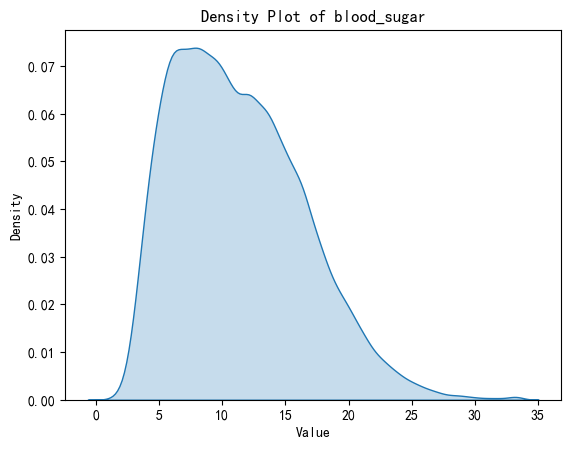

In [11]:
# 使用seaborn绘制KDE图
sns.kdeplot(df['Blood Glucose'], fill=True)  # fill=True表示填充区域
# 添加标题和轴标签
plt.title('Density Plot of blood_sugar')
plt.xlabel('Value')
plt.ylabel('Density')
# 显示图形
plt.show()

In [13]:
# 删除含有 NaN 或空值的行
df.dropna(inplace=True)

In [15]:
# 分离目标变量
target = df['Blood Glucose']
# 将“血糖值“， ”住院流水号“， ”测量时间“， ”频次“删除掉
df = df[['Maximum Blood Glucose', 'Minimum Blood Glucose', 'Mean Blood Glucose in Previous 24h', 
         'Number of Hypoglycemia Episodes', 'Number of Hyperglycemia Episodes', 
         'Previous Blood Glucose Level', 'Second Previous Blood Glucose Level']]



In [17]:
print(df.head())

   Maximum Blood Glucose  Minimum Blood Glucose  \
2                   19.4                   16.0   
3                   19.4                   13.4   
4                   19.4                    7.2   
5                   19.4                    7.2   
6                   19.4                    5.0   

   Mean Blood Glucose in Previous 24h  Number of Hypoglycemia Episodes  \
2                           18.133333                                0   
3                           16.133333                                0   
4                           12.200000                                0   
5                            9.333333                                0   
6                            6.533333                                0   

   Number of Hyperglycemia Episodes  Previous Blood Glucose Level  \
2                                 3                          19.0   
3                                 4                          16.0   
4                                 4      

In [19]:
# 拆分数据集
train_x, test_x, train_y, test_y = train_test_split(df, target, test_size=0.2, random_state=42)

In [21]:
train_x, valid_x, train_y, valid_y = train_test_split(train_x, train_y, test_size=0.25, random_state=42)

In [23]:
def r2_score(y_true, y_pred):
    return 1 - ((y_true - y_pred) ** 2).mean() / ((y_true - y_true.mean()) ** 2).mean()

# 将自定义评估函数封装成 XGBoost 可识别的形式
def custom_r2_score(y_true, y_pred):
    y_true = y_true.get_label()
    y_pred = y_pred
    return 'r2', r2_score(y_true, y_pred)

In [25]:
best_params = {
    'booster': 'gbtree',
    'learning_rate': 0.17161713216911806,
    'max_depth': 3,
    'min_child_weight': 1,
    'subsample': 0.9205290305290692,
    'colsample_bytree': 0.9695174733247519,
    'reg_alpha': 0.32309787954216,
    'reg_lambda': 5.505046834003221e-08,
    'gamma': 0.0009744840445500341,
    'n_estimators': 443*7
}

In [27]:
 model = xgb.XGBRegressor(**best_params)

In [29]:
eval_set = [(train_x, train_y), (valid_x, valid_y)]

In [31]:
print(train_x.head(5))

       Maximum Blood Glucose  Minimum Blood Glucose  \
33393                   23.9                    4.7   
28988                   32.9                    8.9   
46466                   11.2                    5.1   
20228                   21.7                    7.0   
3469                    25.5                    9.4   

       Mean Blood Glucose in Previous 24h  Number of Hypoglycemia Episodes  \
33393                           14.266667                                0   
28988                            9.833333                                0   
46466                            9.033333                                0   
20228                           15.066667                                0   
3469                            16.633333                                0   

       Number of Hyperglycemia Episodes  Previous Blood Glucose Level  \
33393                                25                          14.2   
28988                                 7               

In [33]:
print(train_y.head(5))

33393    15.6
28988     8.9
46466     6.8
20228    18.1
3469     10.2
Name: Blood Glucose, dtype: float64


In [ ]:
model.fit(train_x, train_y,
          eval_set=eval_set,
          verbose=True)

[0]	validation_0-rmse:4.49291	validation_1-rmse:4.52074
[1]	validation_0-rmse:4.07471	validation_1-rmse:4.09580
[2]	validation_0-rmse:3.94012	validation_1-rmse:3.95850
[3]	validation_0-rmse:3.64310	validation_1-rmse:3.66083
[4]	validation_0-rmse:3.40937	validation_1-rmse:3.42439
[5]	validation_0-rmse:3.21936	validation_1-rmse:3.23504
[6]	validation_0-rmse:3.06189	validation_1-rmse:3.08014
[7]	validation_0-rmse:2.92816	validation_1-rmse:2.95116
[8]	validation_0-rmse:2.82012	validation_1-rmse:2.84450
[9]	validation_0-rmse:2.72583	validation_1-rmse:2.75046
[10]	validation_0-rmse:2.64179	validation_1-rmse:2.66920
[11]	validation_0-rmse:2.57885	validation_1-rmse:2.60849
[12]	validation_0-rmse:2.50904	validation_1-rmse:2.53800
[13]	validation_0-rmse:2.43842	validation_1-rmse:2.46721
[14]	validation_0-rmse:2.38345	validation_1-rmse:2.41360
[15]	validation_0-rmse:2.36509	validation_1-rmse:2.39579
[16]	validation_0-rmse:2.31433	validation_1-rmse:2.34676
[17]	validation_0-rmse:2.25081	validation

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9695174733247519, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0.0009744840445500341,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.17161713216911806,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=3101, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [36]:
#训练
y_pred_train = model.predict(train_x)
mse_train = mean_squared_error(train_y, y_pred_train) #均方误差
R2_train = r2_score(train_y, y_pred_train)
print(f"Mean Squared Error: {mse_train}")
print(f"R2_train: {r2_score(train_y, y_pred_train)}")

Mean Squared Error: 0.020415312373170805
R2_train: 0.9991867395663355


In [38]:
#均方根误差 (RMSE)  平均绝对误差 (MAE)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(train_y, y_pred_train)
print(f"Root Mean Squared Error : {rmse_train}")
print(f"Mean Absolute Error : {mae_train}")

Root Mean Squared Error : 0.14288216254372274
Mean Absolute Error : 0.11035233686061145


In [40]:
#验证
y_pred_valid = model.predict(valid_x)
mse_valid = mean_squared_error(valid_y, y_pred_valid) #均方误差
R2_vaild = r2_score(valid_y, y_pred_valid)
print(f"Mean Squared Error: {mse_valid}")
print(f"R2_valid: {r2_score(valid_y, y_pred_valid)}")

Mean Squared Error: 0.1043849442392443
R2_valid: 0.9958938399129038


In [42]:
#均方根误差 (RMSE)  平均绝对误差 (MAE)
rmse_valid = np.sqrt(mse_valid)
mae_valid = mean_absolute_error(valid_y, y_pred_valid)
print(f"Root Mean Squared Error : {rmse_valid}")
print(f"Mean Absolute Error : {mae_valid}")

Root Mean Squared Error : 0.3230865893831626
Mean Absolute Error : 0.15580085122209883


In [44]:
# 保存模型
model.save_model('final_xgb_model.json')

In [46]:
model = xgb.XGBRegressor()

In [48]:
# 加载模型
model.load_model('final_xgb_model.json')

In [50]:
# 预测并评估
y_pred_test = model.predict(test_x)
mse_test = mean_squared_error(test_y, y_pred_test)
R2_test=r2_score(test_y, y_pred_test)
print(f"Mean Squared Error: {mse_test}")
print(f"R2_test: {r2_score(test_y, y_pred_test)}")

Mean Squared Error: 0.09969574762051145
R2_test: 0.9960253677552303


In [52]:
#均方根误差 (RMSE)  平均绝对误差 (MAE)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(test_y, y_pred_test)
print(f"Root Mean Squared Error : {rmse_test}")
print(f"Mean Absolute Error : {mae_test}")

Root Mean Squared Error : 0.3157463342946541
Mean Absolute Error : 0.15520194358347839


In [54]:
print(test_y.head(10))

12420    25.1
4332     17.0
18458     7.5
48708    15.0
40435     8.3
42261     4.7
37484     7.4
20533    20.1
46890    11.3
29510    10.9
Name: Blood Glucose, dtype: float64


In [58]:
#测试集进行预测
print(y_pred_test[:10])

[24.97542  17.120926  7.512856 15.127818  8.373029  4.693344  7.592331
 20.085794 11.308376 11.038293]


In [60]:
print(df.head())

   Maximum Blood Glucose  Minimum Blood Glucose  \
2                   19.4                   16.0   
3                   19.4                   13.4   
4                   19.4                    7.2   
5                   19.4                    7.2   
6                   19.4                    5.0   

   Mean Blood Glucose in Previous 24h  Number of Hypoglycemia Episodes  \
2                           18.133333                                0   
3                           16.133333                                0   
4                           12.200000                                0   
5                            9.333333                                0   
6                            6.533333                                0   

   Number of Hyperglycemia Episodes  Previous Blood Glucose Level  \
2                                 3                          19.0   
3                                 4                          16.0   
4                                 4      

## 1.模型指标可视化

In [63]:
# 将指标放入列表
metrics_labels = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics = [mse_train, rmse_train, mae_train, R2_train]
valid_metrics = [mse_valid, rmse_valid, mae_valid, R2_vaild]
test_metrics = [mse_test, rmse_test, mae_test, R2_test]

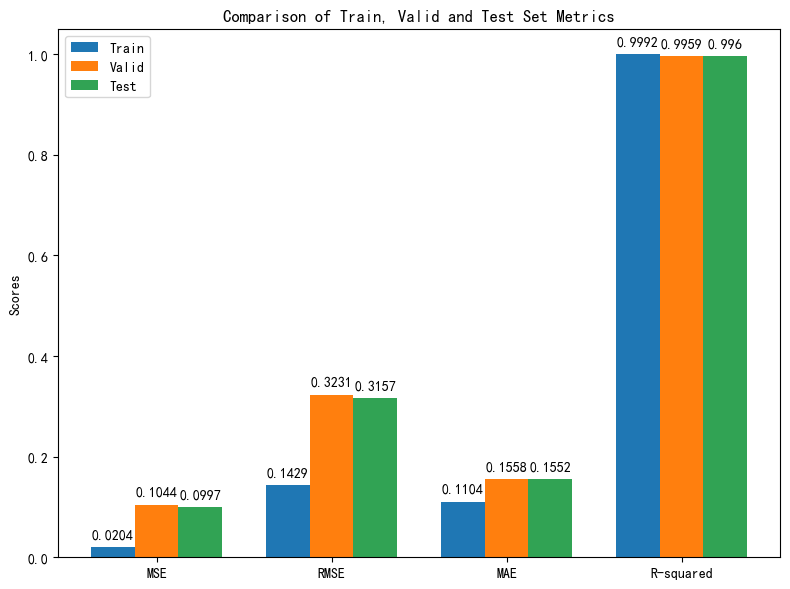

In [65]:
# 创建柱状图
x = np.arange(len(metrics_labels))  # 横坐标位置
width = 0.25# 柱子的宽度


fig, ax = plt.subplots(figsize=(8, 6))  # 调整图形大小

# 训练集和测试集的柱子
bars1 = ax.bar(x - width, train_metrics, width, label='Train')  
bars2 = ax.bar(x, valid_metrics, width, label='Valid')        
bars3 = ax.bar(x + width, test_metrics, width, label='Test',color="#31a354")   


# 添加标签和标题
ax.set_ylabel('Scores')
ax.set_title('Comparison of Train, Valid and Test Set Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)  
ax.legend(loc='upper left')

# 在每个柱子上显示数值
def autolabel(bars):
    """在每个柱子上显示数值."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(round(height, 4)),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # 3 点垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom',
                    )  # 缩小字体)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

fig.tight_layout()
plt.savefig("Comparison of Train, Valid and Test Set Metrics.pdf", format='pdf',bbox_inches='tight')
plt.show()


In [67]:
##问题？需不需要增加验证集的评价指标

## 2.获取特征重要性(第一种方法)

In [70]:
import numpy as np

model.feature_importances_ 在使用 XGBoost 或其他决策树模型时，通常返回的是特征的重要性得分，这些得分基于各个特征在构建树时对模型预测误差的改进程度。这些重要性得分是通过计算特征在树中使用时对预测准确性的贡献或是分裂所减少的不纯度（例如 Gini 不纯度或均方误差）来得出的。然而，这不是 SHAP（SHapley Additive exPlanations）值。SHAP 值是基于博弈论中的 Shapley 值来解释模型预测的一个方法。它考虑了所有可能的特征组合来决定每个特征对于给定预测的贡献度。SHAP 值可以提供比传统特征重要性更深入、更细致的解释，因为它不仅表明了特征的重要性，还显示了特征值如何影响模型的输出。

In [73]:
# 获取XGBoost模型的特征贡献度（重要性）
feature_importances = model.feature_importances_

In [75]:
sorted_indices = np.argsort(feature_importances)[::-1]  # 逆序排列，重要性从高到低
sorted_features = train_x.columns[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

In [77]:
for feature_name, importance in zip(sorted_features, sorted_importances):    
    print(f"Feature: {feature_name}, Importance: {importance:.4f}")

Feature: Mean Blood Glucose in Previous 24h, Importance: 0.6085
Feature: Second Previous Blood Glucose Level, Importance: 0.1864
Feature: Previous Blood Glucose Level, Importance: 0.1631
Feature: Minimum Blood Glucose, Importance: 0.0178
Feature: Maximum Blood Glucose, Importance: 0.0172
Feature: Number of Hyperglycemia Episodes, Importance: 0.0046
Feature: Number of Hypoglycemia Episodes, Importance: 0.0024


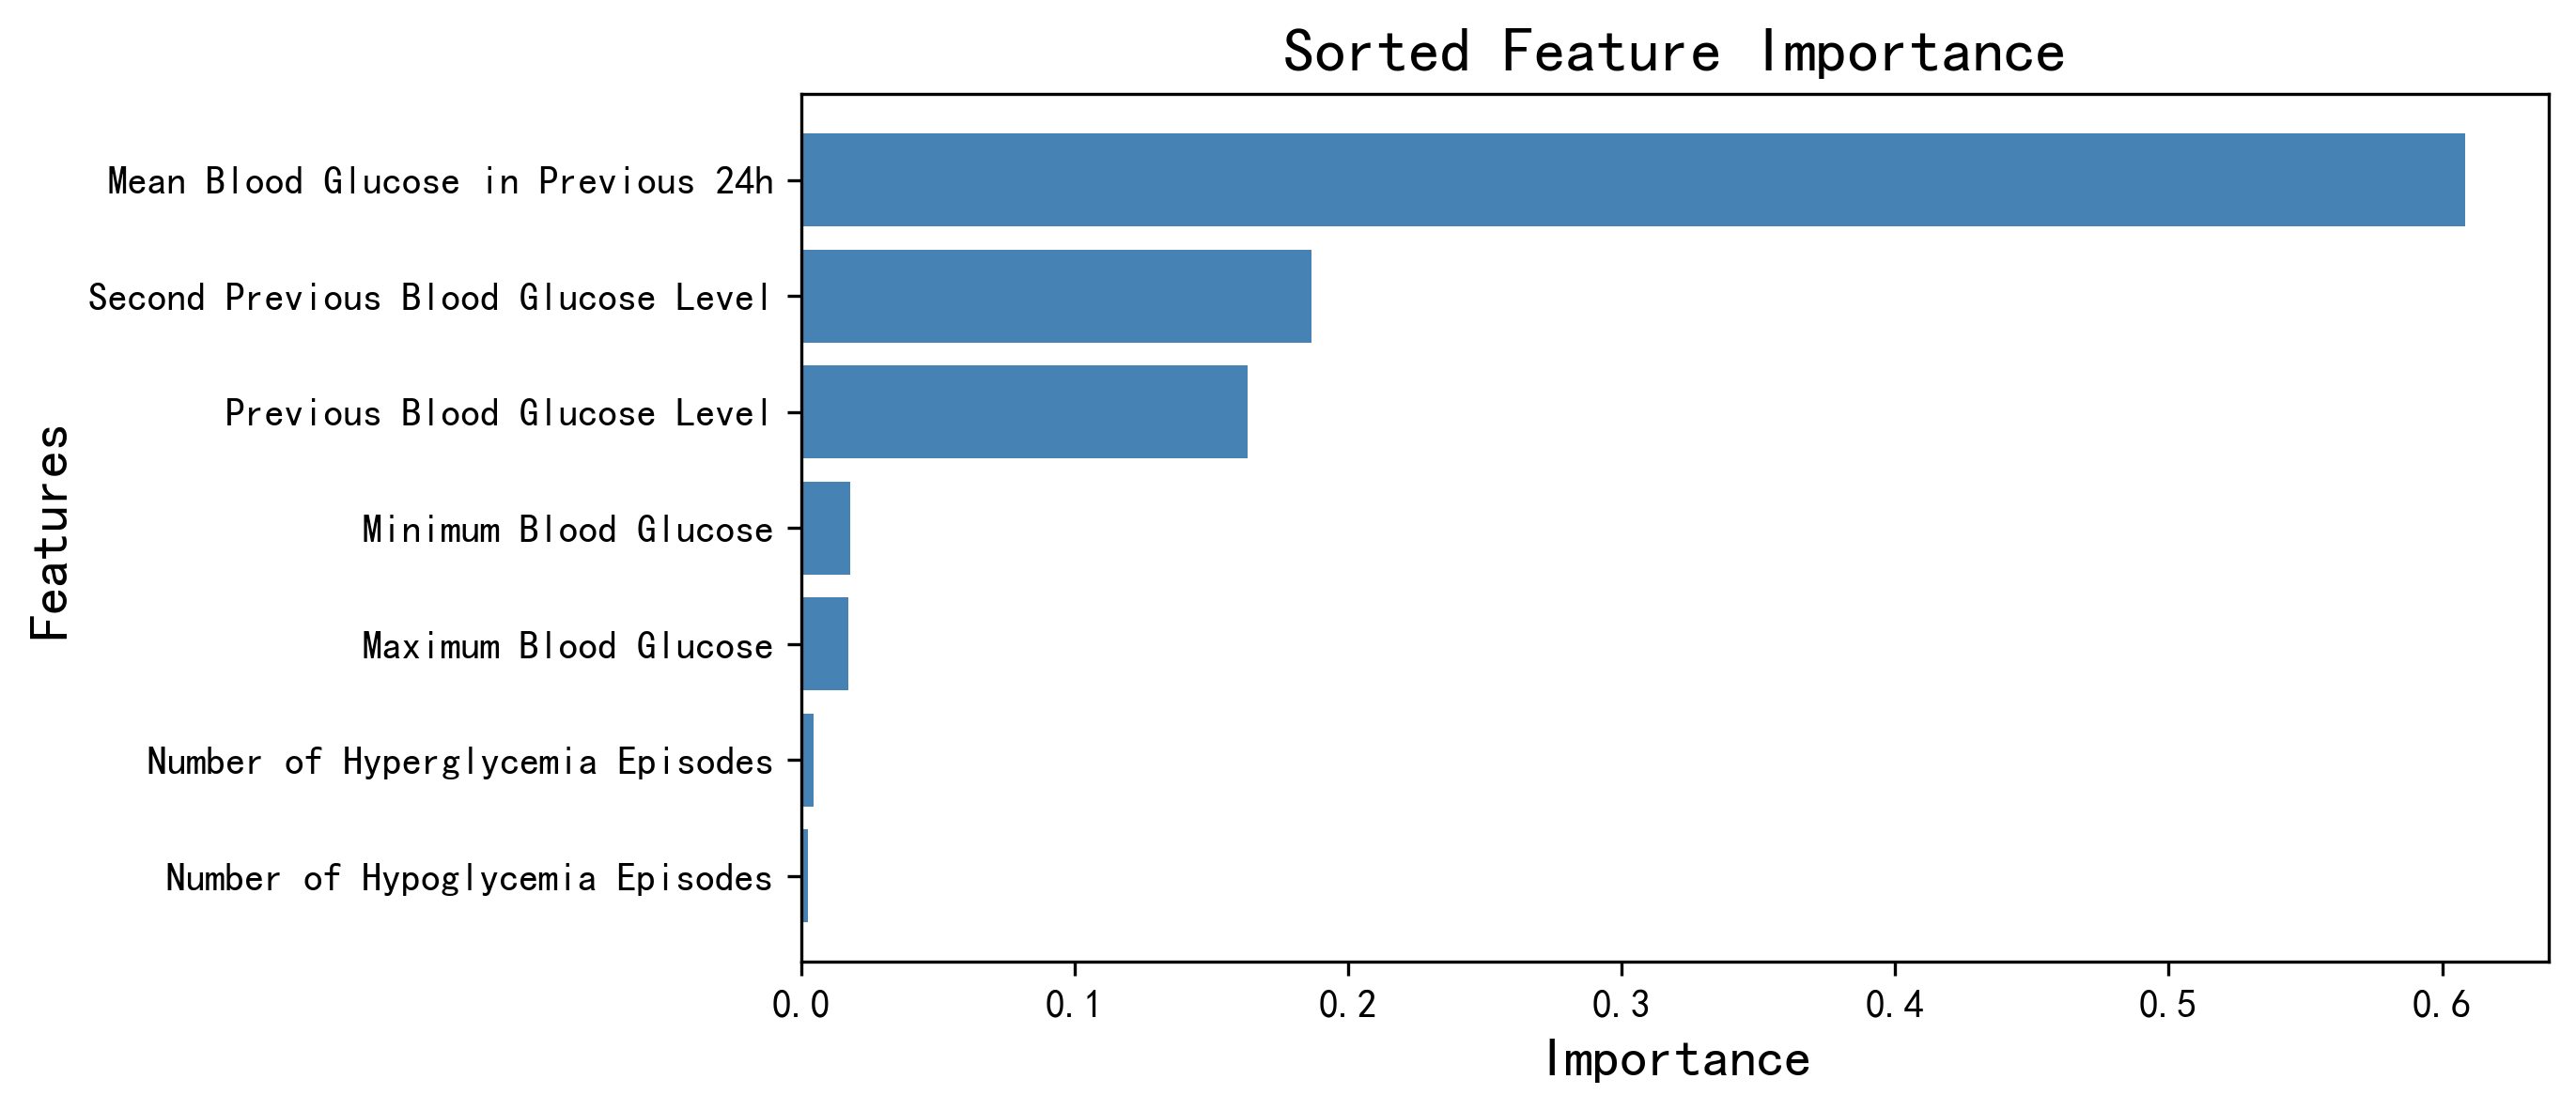

In [81]:
import matplotlib.pyplot as plt

# 绘制按重要性排序的特征贡献性柱状图
plt.figure(figsize=(8,4), dpi=300)  # 设置图表尺寸和分辨率
plt.barh(sorted_features, sorted_importances, color='steelblue')  # 绘制水平柱状图
plt.xlabel('Importance', fontsize=14)  # 设置 x 轴标签
plt.ylabel('Features', fontsize=14)  # 设置 y 轴标签
plt.title('Sorted Feature Importance', fontsize=16)  # 设置图表标题
plt.gca().invert_yaxis()  # 反转 y 轴，使重要性高的特征在上方

plt.show()  # 显示图表


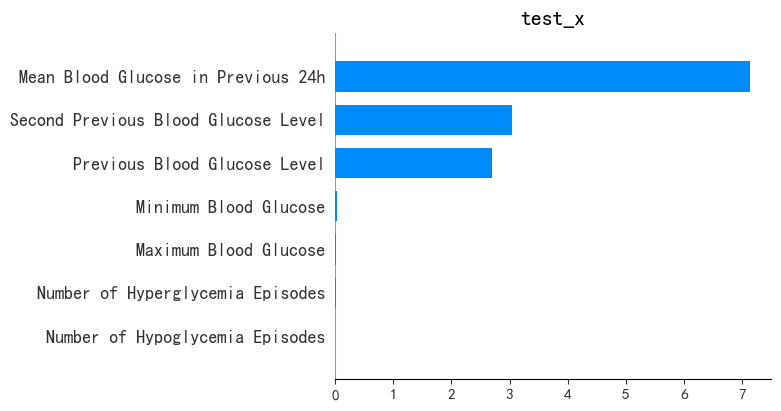

In [83]:

import shap
# 构建 shap解释器
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(test_x)


# 特征标签
labels = test_x.columns
plt.rcParams['font.family'] = 'SimHei'  # 或 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题
plt.rcParams['font.size'] = 13

# 绘制SHAP值总结图（Summary Plot）
plt.figure(figsize=(20, 5))
shap.summary_plot(shap_values, test_x, plot_type="bar", show=False)#默认情况下只会显示影响最大的前20 个特征
plt.title("test_x")
plt.xlabel('')  
plt.tight_layout()
plt.show()


###注意展示的不是文献所需的特征贡献图，SHAP值是一种解释模型预测的方法，通过计算每个特征对预测结果的贡献度，我们可以了解哪些特征对模型的影响最大，并依据这些贡献度来排序特征，从而筛选出重要特征

测试集（test_x）是用于评估模型泛化性能的数据集。在模型训练完成后，用未见过的数据（即测试集）来评估其性能。
在使用 SHAP（SHapley Additive exPlanations）进行解释时，通常我们会基于测试集计算 SHAP 值，因为我们想知道模型在未见过的数据上的表现及其背后的解释。
这种方式可以告诉我们模型在真实场景或新数据上对每个特征的依赖程度。

SHAP值是一种解释模型预测的方法，通过计算每个特征对预测结果的贡献度，我们可以了解哪些特征对模型的影响最大，并依据这些贡献度来排序特征，从而筛选出重要特征

使用sorted_indices重新排列数据集的特征，使得最重要的特征排在前面，这样排列后的数据集便于后续在不同特征组合下评估模型性能，特别是在进行逐步特征添加和蒙特卡洛模拟时，可以优先考虑贡献度大的特征

## 3.回归结果可视化

In [85]:
import seaborn as sns
from sklearn import metrics

In [87]:
y_pred_train = model.predict(train_x)

In [89]:
# 创建一个包含训练集和测试集真实值与预测值的数据框
data_train = pd.DataFrame({
    'True': train_y,
    'Predicted': y_pred_train,
    'Data Set': 'Train'
})

data_test = pd.DataFrame({
    'True': test_y,
    'Predicted': y_pred_test,
    'Data Set': 'Test'
})

data = pd.concat([data_train, data_test])

In [91]:
print(f"train_y length: {len(train_y)}")
print(f"y_pred_train length: {len(y_pred_train)}")

print(f"test_y length: {len(test_y)}")
print(f"y_pred_test length: {len(y_pred_test)}")


train_y length: 29816
y_pred_train length: 29816
test_y length: 9939
y_pred_test length: 9939


In [93]:
# 自定义调色板
palette = {'Train': '#b4d4e1', 'Test': '#f4ba8a'}

D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 2400x1800 with 0 Axes>

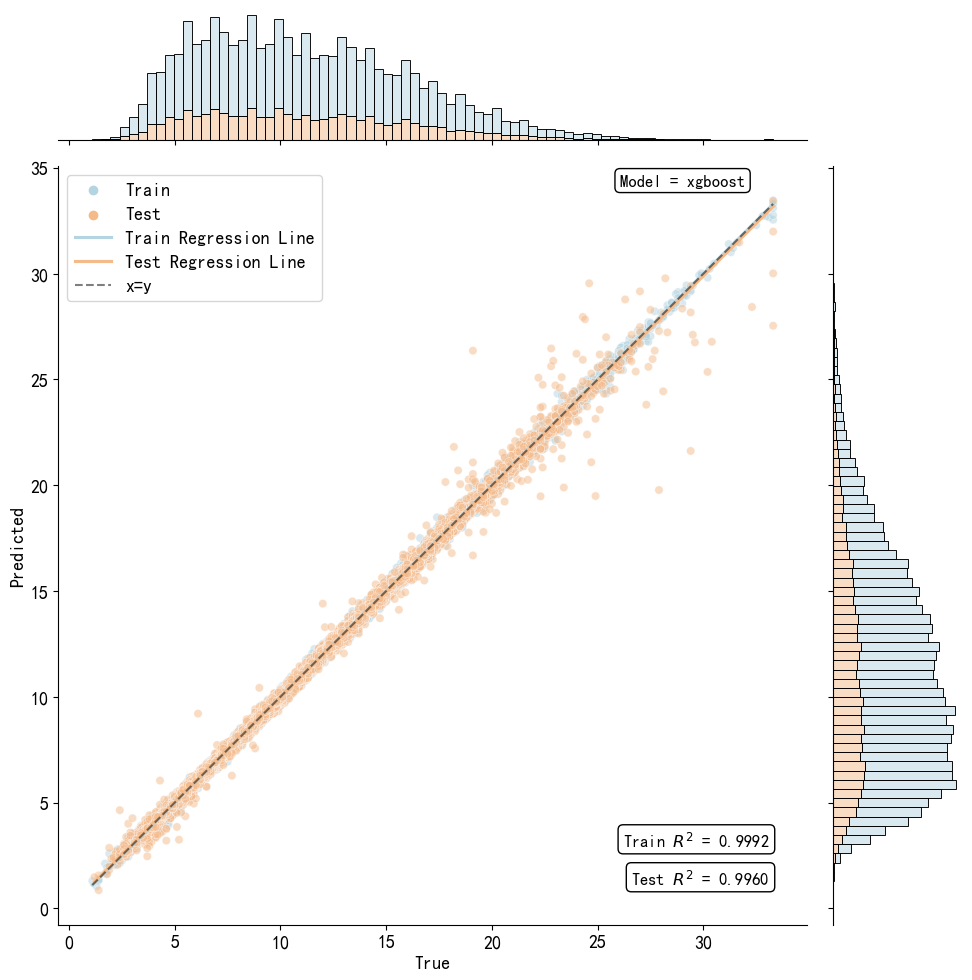

In [95]:
# 创建 JointGrid 对象
plt.figure(figsize=(8,6 ), dpi=300)
g = sns.JointGrid(data=data, x="True", y="Predicted", hue="Data Set", height=10, palette=palette)
# 绘制中心的散点图
g.plot_joint(sns.scatterplot, alpha=0.5)
# 添加训练集的回归线
sns.regplot(data=data_train, x="True", y="Predicted", scatter=False, ax=g.ax_joint, color='#b4d4e1', label='Train Regression Line')
# 添加测试集的回归线
sns.regplot(data=data_test, x="True", y="Predicted", scatter=False, ax=g.ax_joint, color='#f4ba8a', label='Test Regression Line')
# 添加边缘的柱状图
g.plot_marginals(sns.histplot, kde=False, element='bars', multiple='stack', alpha=0.5)
# 添加拟合优度文本在右下角
ax = g.ax_joint
ax.text(0.95, 0.1, f'Train $R^2$ = {R2_train:.4f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))
ax.text(0.95, 0.05, f'Test $R^2$ = {R2_test:.4f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))
# 在左上角添加模型名称文本
ax.text(0.75, 0.99, 'Model = xgboost', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))
# 添加中心线
ax.plot([data['True'].min(), data['True'].max()], [data['True'].min(), data['True'].max()], c="black", alpha=0.5, linestyle='--', label='x=y')
ax.legend()
plt.savefig("TrueFalse.pdf", format='pdf', bbox_inches='tight')

# 关闭 y 轴的边缘柱状图
#g.ax_marg_y.set_visible(False)
plt.show()

## 4.测试值和预测值可视化

In [97]:
# 计算测试集残差和标准差（使用 ddof=1 来计算样本标准差）
residuals_simulated = test_y -y_pred_test
sigma_simulated = np.std(residuals_simulated, ddof=1)

In [99]:
# 计算三种置信区间
conf_intervals_simulated = {
    'mu ± sigma': (y_pred_test - sigma_simulated, y_pred_test + sigma_simulated),
    'mu ± 2sigma': (y_pred_test - 2*sigma_simulated, y_pred_test + 2*sigma_simulated),
    'mu ± 3sigma': (y_pred_test - 3*sigma_simulated, y_pred_test + 3*sigma_simulated),
}

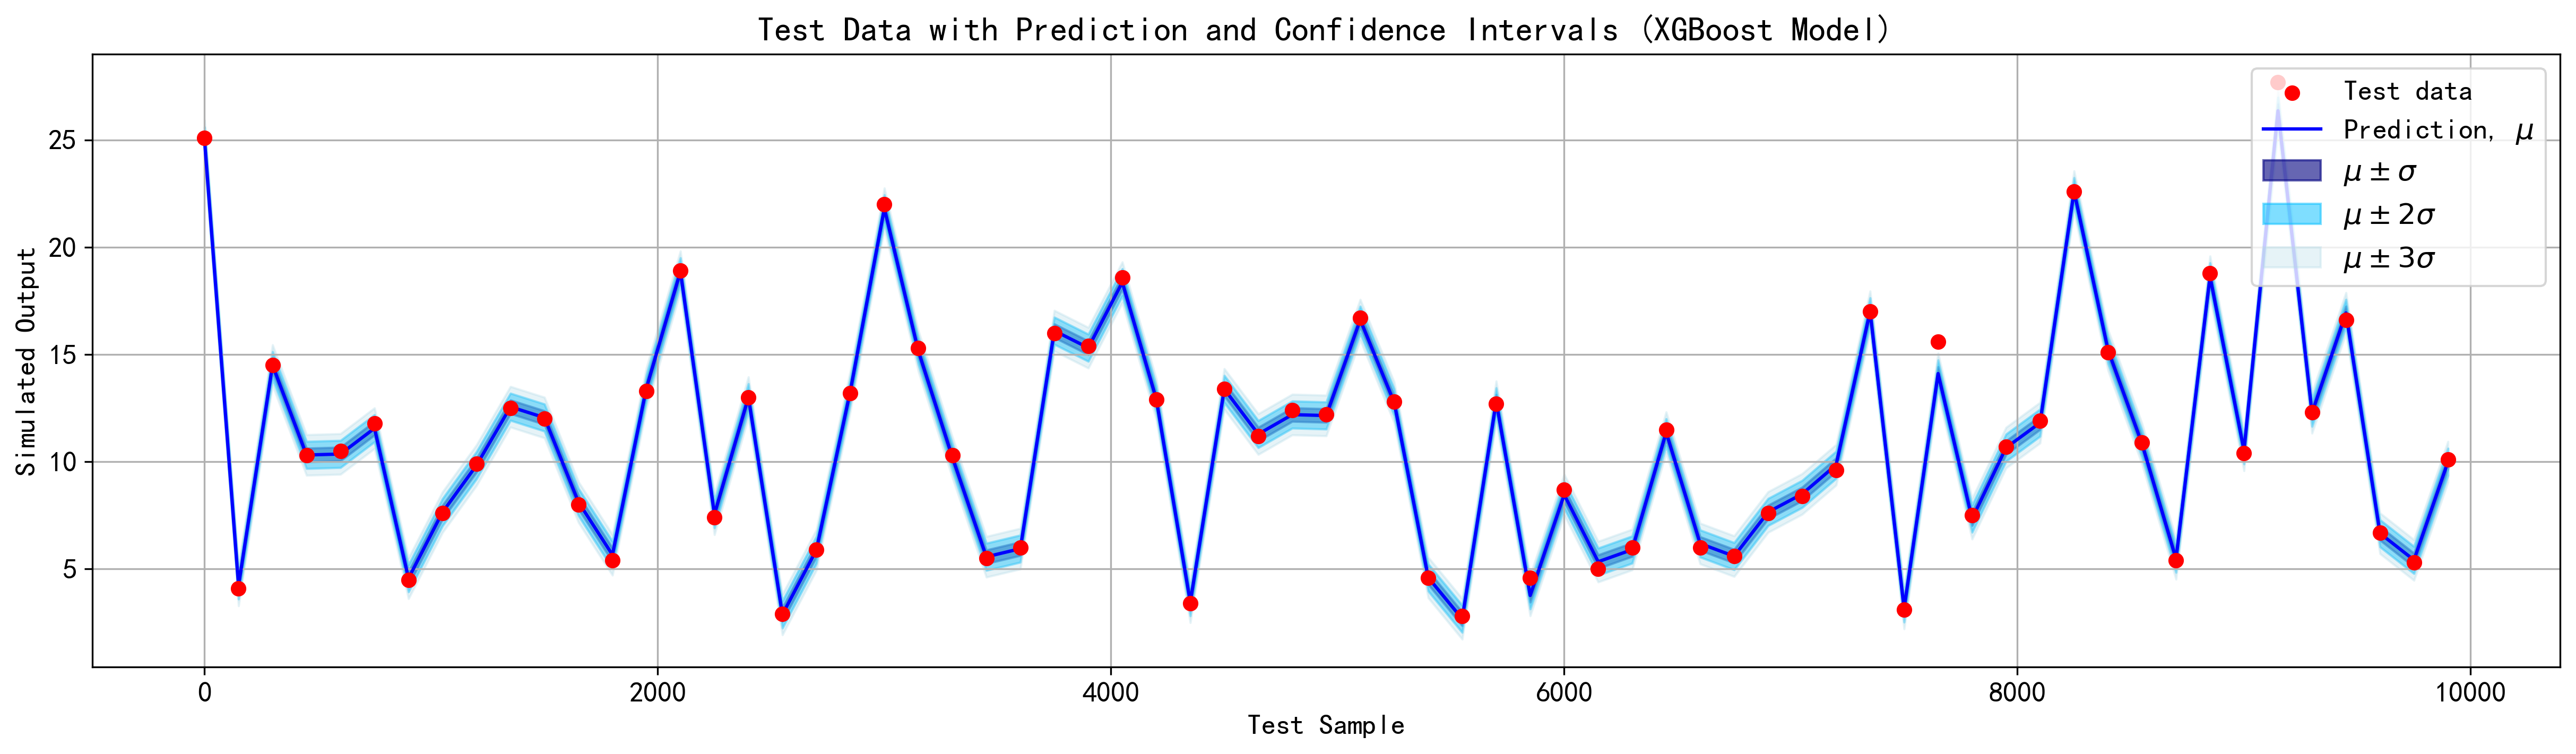

In [101]:
# 模拟数据加载和降采样操作

test_indices_simulated = np.arange(len(test_y))  # 模拟的索引数组

# 选择每100个点中的一个点进行绘图,全放进去太复杂
sample_rate = 150
test_indices_sampled = test_indices_simulated[::sample_rate]
test_y_sampled = test_y[::sample_rate]
y_pred_test_sampled = y_pred_test[::sample_rate]

# 置信区间数据降采样
sigma_lower_sampled = conf_intervals_simulated['mu ± sigma'][0][::sample_rate]
sigma_upper_sampled = conf_intervals_simulated['mu ± sigma'][1][::sample_rate]
sigma_2_lower_sampled = conf_intervals_simulated['mu ± 2sigma'][0][::sample_rate]
sigma_2_upper_sampled = conf_intervals_simulated['mu ± 2sigma'][1][::sample_rate]
sigma_3_lower_sampled = conf_intervals_simulated['mu ± 3sigma'][0][::sample_rate]
sigma_3_upper_sampled = conf_intervals_simulated['mu ± 3sigma'][1][::sample_rate]

# 绘制可视化图像
plt.figure(figsize=(20, 5), dpi=300)  # 设置图形大小和分辨率

# 绘制测试数据
plt.scatter(test_indices_sampled, test_y_sampled, color='red', label='Test data', zorder=5)

# 绘制预测均值
plt.plot(test_indices_sampled, y_pred_test_sampled, color='blue', label='Prediction, $\\mu$', zorder=4)

# 绘制三种置信区间
plt.fill_between(test_indices_sampled, sigma_lower_sampled, sigma_upper_sampled, 
                 color='navy', alpha=0.6, label='$\\mu \\pm \\sigma$')
plt.fill_between(test_indices_sampled, sigma_2_lower_sampled, sigma_2_upper_sampled, 
                 color='deepskyblue', alpha=0.5, label='$\\mu \\pm 2\\sigma$')
plt.fill_between(test_indices_sampled, sigma_3_lower_sampled, sigma_3_upper_sampled, 
                 color='lightblue', alpha=0.3, label='$\\mu \\pm 3\\sigma$')

# 设置图表标题和标签
plt.title('Test Data with Prediction and Confidence Intervals (XGBoost Model)')
plt.xlabel('Test Sample')
plt.ylabel('Simulated Output')
plt.legend(loc='upper right')  # 调整图例位置
plt.grid(True)  # 添加网格
plt.savefig("Test Data with Prediction and Confidence Intervals (XGBoost Model).pdf", bbox_inches='tight')  # 保存图像
plt.show()  # 显示图像
